# 01 - EDA：主表 (base) 与 静态申请信息 (static)

**目标**: 理解数据分布、目标变量、时间结构、缺失值，为后续特征工程与样本设计提供依据。

**分析范围**: 
- `base` 表：目标变量、时间维度 (WEEK_NUM / MONTH)
- `static` 表：关键字段分布、缺失值、与目标变量的关系

**数据规模**: 
- base: ~152万行 × 5列
- static: ~152万行 × 168列（分 static_0_0 + static_0_1 两文件）

In [ ]:
# ============================================================
# 0. 环境配置与库导入
# ============================================================
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 解决 Matplotlib 中文显示方框问题（Windows 终极方案）
# ============================================================
from matplotlib import font_manager

# 直接加载 Windows 系统字体文件（最可靠，不依赖缓存扫描）
font_paths = [
    'C:/Windows/Fonts/msyh.ttc',      # Microsoft YaHei
    'C:/Windows/Fonts/simhei.ttf',    # SimHei
    'C:/Windows/Fonts/simsun.ttc',    # SimSun
]

chinese_font = None
for fp in font_paths:
    if Path(fp).exists():
        try:
            font_manager.fontManager.addfont(fp)
            prop = font_manager.FontProperties(fname=fp)
            plt.rcParams['font.family'] = prop.get_name()
            plt.rcParams['axes.unicode_minus'] = False
            chinese_font = prop.get_name()
            print(f'✅ 字体加载成功: {fp} → 字体名: {chinese_font}')
            break
        except Exception as e:
            print(f'⚠️ 加载字体失败 {fp}: {e}')

if not chinese_font:
    print('❌ 所有字体文件加载失败，中文将显示为方框')

sns.set_style('whitegrid')

# 数据路径
DATA_DIR = Path('E:/cursor/PROJECT/home_credit_default_risk/home_credit_crms_2024')
TRAIN_DIR = DATA_DIR / 'parquet_files' / 'train'
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(exist_ok=True)

print('环境配置完成')

## 1. Base 表加载与概览

In [2]:
# ============================================================
# 1.1 加载 base 表
# ============================================================
base = pd.read_parquet(TRAIN_DIR / 'train_base.parquet')

print(f"base 表维度: {base.shape}")
print(f"\n字段信息:")
print(base.dtypes)
print(f"\n前5行:")
display(base.head())
print(f"\n缺失值:")
print(base.isnull().sum())

base 表维度: (1526659, 5)

字段信息:
case_id          int64
date_decision      str
MONTH            int64
WEEK_NUM         int64
target           int64
dtype: object

前5行:


,case_id,date_decision,MONTH,WEEK_NUM,target
0,0,2019-01-03,201901,0,0
1,1,2019-01-03,201901,0,0
2,2,2019-01-04,201901,0,0
3,3,2019-01-03,201901,0,0
4,4,2019-01-04,201901,0,1



缺失值:
case_id          0
date_decision    0
MONTH            0
WEEK_NUM         0
target           0
dtype: int64


目标变量分布:
target
0    1478665
1      47994
Name: count, dtype: int64

目标变量占比:
  target=0: 96.8563%
  target=1: 3.1437%


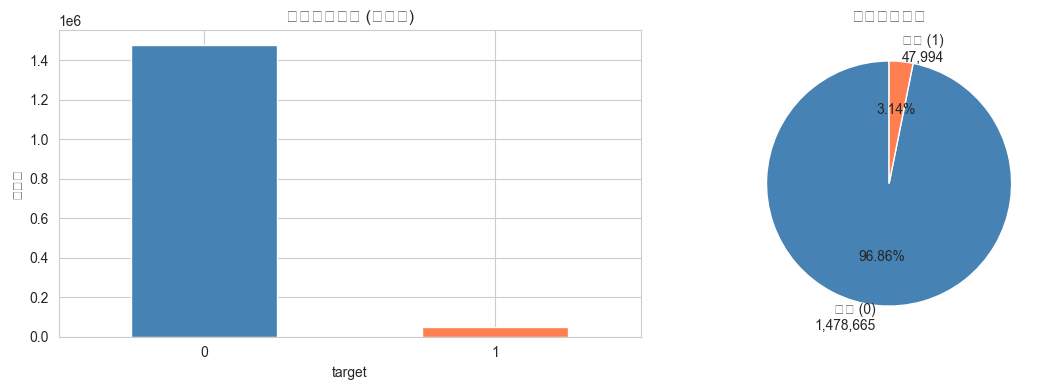


⚠️ 样本极度不平衡，违约率仅 3.1437%，后续建模需考虑采样或类别权重。


In [3]:
# ============================================================
# 1.2 目标变量 (target) 分布分析
# ============================================================
target_counts = base['target'].value_counts().sort_index()
target_ratio = base['target'].value_counts(normalize=True).sort_index()

print("目标变量分布:")
print(target_counts)
print(f"\n目标变量占比:")
for k, v in target_ratio.items():
    print(f"  target={k}: {v:.4%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 柱状图
target_counts.plot(kind='bar', ax=ax[0], color=['steelblue', 'coral'])
ax[0].set_title('目标变量分布 (绝对数)', fontsize=12)
ax[0].set_xlabel('target')
ax[0].set_ylabel('样本数')
ax[0].tick_params(axis='x', rotation=0)

# 饼图
ax[1].pie(target_counts, labels=[f'正常 (0)\n{target_counts[0]:,}', f'违约 (1)\n{target_counts[1]:,}'], 
          autopct='%1.2f%%', startangle=90, colors=['steelblue', 'coral'])
ax[1].set_title('目标变量占比', fontsize=12)

plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n⚠️ 样本极度不平衡，违约率仅 {target_ratio[1]:.4%}，后续建模需考虑采样或类别权重。")

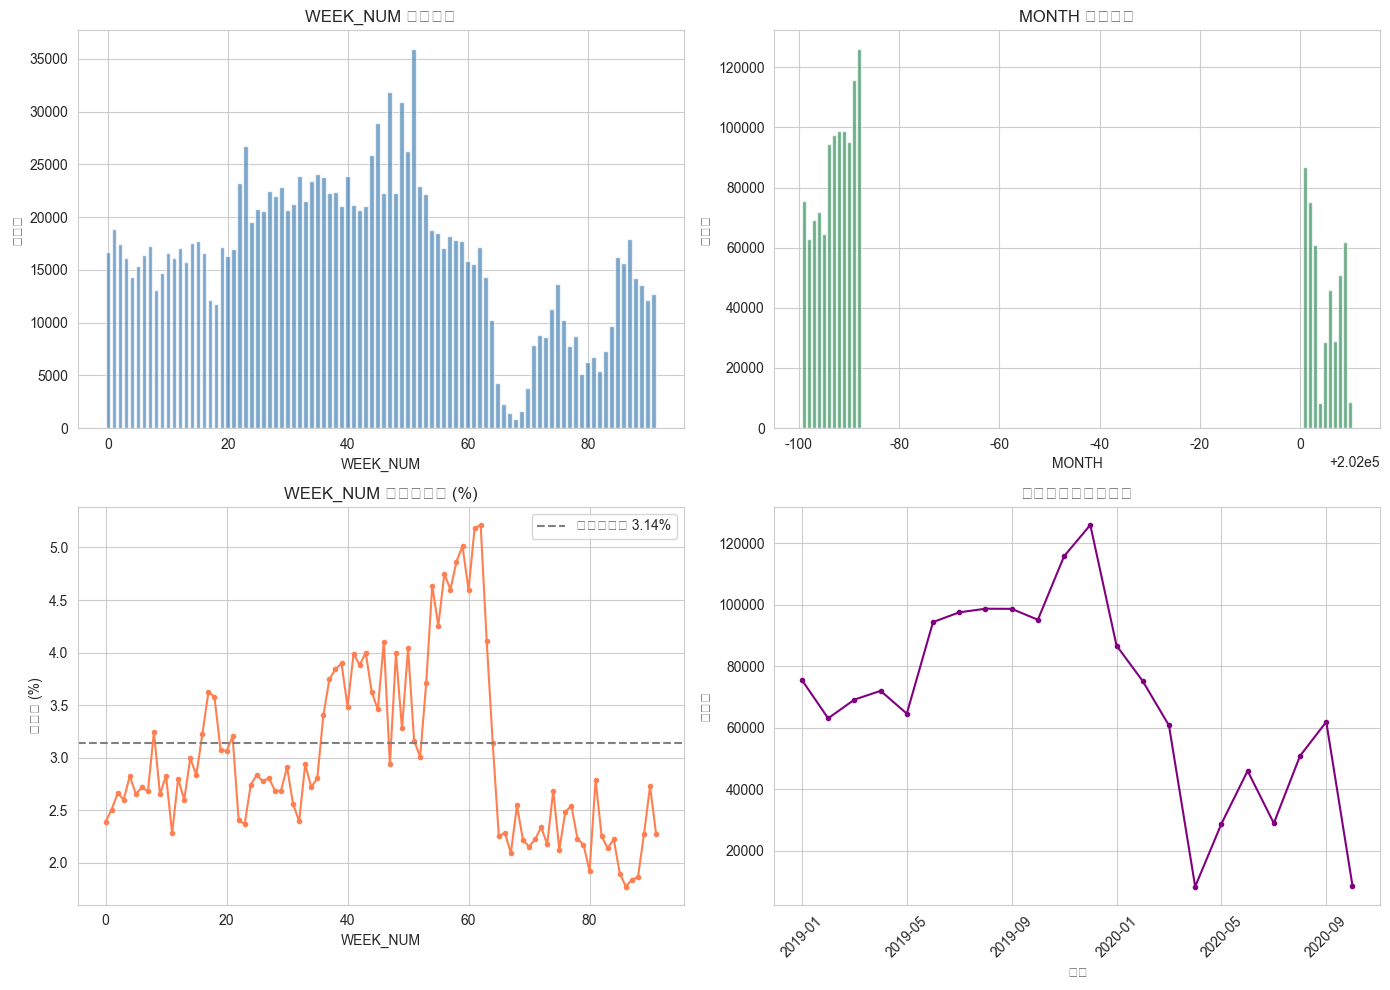

WEEK_NUM 范围: 0 ~ 91，共 92 周
MONTH 范围: 201901 ~ 202010，共 22 个月
日期范围: 2019-01-01 00:00:00 ~ 2020-10-05 00:00:00

⚠️ WEEK_NUM 违约率波动范围: 1.77% ~ 5.21%


In [4]:
# ============================================================
# 1.3 时间维度分析：WEEK_NUM 与 MONTH
# ============================================================
base['date_decision'] = pd.to_datetime(base['date_decision'])

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# --- WEEK_NUM 分布 ---
week_counts = base['WEEK_NUM'].value_counts().sort_index()
ax[0, 0].bar(week_counts.index, week_counts.values, color='steelblue', alpha=0.7)
ax[0, 0].set_title('WEEK_NUM 样本分布', fontsize=12)
ax[0, 0].set_xlabel('WEEK_NUM')
ax[0, 0].set_ylabel('样本数')

# --- MONTH 分布 ---
month_counts = base['MONTH'].value_counts().sort_index()
ax[0, 1].bar(month_counts.index, month_counts.values, color='seagreen', alpha=0.7)
ax[0, 1].set_title('MONTH 样本分布', fontsize=12)
ax[0, 1].set_xlabel('MONTH')
ax[0, 1].set_ylabel('样本数')

# --- WEEK_NUM 违约率趋势 ---
week_default = base.groupby('WEEK_NUM')['target'].agg(['mean', 'count']).reset_index()
ax[1, 0].plot(week_default['WEEK_NUM'], week_default['mean'] * 100, color='coral', marker='o', markersize=3)
ax[1, 0].set_title('WEEK_NUM 违约率趋势 (%)', fontsize=12)
ax[1, 0].set_xlabel('WEEK_NUM')
ax[1, 0].set_ylabel('违约率 (%)')
ax[1, 0].axhline(y=base['target'].mean()*100, color='gray', linestyle='--', label=f'整体违约率 {base["target"].mean()*100:.2f}%')
ax[1, 0].legend()

# --- date_decision 时间线 ---
base['year_month'] = base['date_decision'].dt.to_period('M')
ym_counts = base['year_month'].value_counts().sort_index()
ax[1, 1].plot(ym_counts.index.astype(str), ym_counts.values, color='purple', marker='o', markersize=3)
ax[1, 1].set_title('按审批月份样本分布', fontsize=12)
ax[1, 1].set_xlabel('年月')
ax[1, 1].set_ylabel('样本数')
ax[1, 1].tick_params(axis='x', rotation=45)
n_ticks = len(ym_counts) // 6 + 1
ax[1, 1].set_xticks(ax[1, 1].get_xticks()[::n_ticks])

plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"WEEK_NUM 范围: {base['WEEK_NUM'].min()} ~ {base['WEEK_NUM'].max()}，共 {base['WEEK_NUM'].nunique()} 周")
print(f"MONTH 范围: {base['MONTH'].min()} ~ {base['MONTH'].max()}，共 {base['MONTH'].nunique()} 个月")
print(f"日期范围: {base['date_decision'].min()} ~ {base['date_decision'].max()}")
print(f"\n⚠️ WEEK_NUM 违约率波动范围: {week_default['mean'].min()*100:.2f}% ~ {week_default['mean'].max()*100:.2f}%")

## 2. Static 表关键字段分析

static 表共 168 个字段，全量加载内存占用大。此处选择 **Tier 1 / Tier 2 关键字段** 进行重点分析。

In [5]:
# ============================================================
# 2.1 定义关键字段列表（基于业务指南中的 Tier 1/2 字段）
# ============================================================
KEY_STATIC_COLS = [
    'case_id',
    # --- DPD / 还款行为 (Tier 1) ---
    'actualdpdtolerance_344P',
    'maxdpdlast12m_727P',
    'maxdpdlast24m_143P',
    'maxdpdlast3m_392P',
    'maxdpdlast6m_474P',
    'avgdbddpdlast24m_3658932P',
    'avgdbddpdlast3m_4187120P',
    'mindbddpdlast24m_3658935P',
    'maxdpdtolerance_374P',
    # --- 期数统计 ---
    'numinstpaidearly3d_3546850L',
    'numinstpaidlate1d_3546852L',
    'numinstlswithdpd10_728L',
    'numinstlswithoutdpd_562L',
    'numinstunpaidmax_3546851L',
    'pctinstlsallpaidlate1d_3546856L',
    'pctinstlsallpaidearl3d_427L',
    # --- 金额 / 债务 ---
    'credamount_770A',
    'downpmt_116A',
    'annuity_780A',
    'currdebt_22A',
    'totaldebt_9A',
    'totalsettled_863A',
    'sumoutstandtotal_3546847A',
    # --- 申请频次 / 多头 ---
    'applications30d_658L',
    'applicationcnt_361L',
    'numrejects9m_859L',
    'numactivecreds_622L',
    'numcontrs3months_479L',
    # --- 产品 / 利率 ---
    'credtype_322L',
    'interestrate_311L',
    'eir_270L',
    'tenor_203L',
    # --- 历史快照 ---
    'lastrejectreason_759M',
    'lastst_736L',
    # --- 收入 / 职业 ---
    'maininc_215A',
    'mainoccupationinc_384A',
    # --- 反欺诈关联 ---
    'mobilephncnt_593L',
    'clientscnt12m_3712952L',
    'clientscnt3m_3712950L',
    # --- 支付渠道 ---
    'pmtnum_254L',
    'paytype_783L',
    # --- 其他 ---
    'deferredmnthsnum_166L',
    'opencred_647L',
]

print(f'选定关键字段数: {len(KEY_STATIC_COLS)}')

选定关键字段数: 44


In [6]:
# ============================================================
# 2.2 加载 static 关键字段（分两个文件加载后合并）
# ============================================================
static_0 = pd.read_parquet(TRAIN_DIR / 'train_static_0_0.parquet', columns=KEY_STATIC_COLS)
static_1 = pd.read_parquet(TRAIN_DIR / 'train_static_0_1.parquet', columns=KEY_STATIC_COLS)
static = pd.concat([static_0, static_1], ignore_index=True)

# 释放内存
del static_0, static_1

print(f"static 关键字段表维度: {static.shape}")
print(f"\n数据类型概览:")
print(static.dtypes.value_counts())

ArrowInvalid: No match for FieldRef.Name(tenor_203L) in case_id: int64
actualdpdtolerance_344P: double
amtinstpaidbefduel24m_4187115A: double
annuity_780A: double
annuitynextmonth_57A: double
applicationcnt_361L: double
applications30d_658L: double
applicationscnt_1086L: double
applicationscnt_464L: double
applicationscnt_629L: double
applicationscnt_867L: double
avgdbddpdlast24m_3658932P: double
avgdbddpdlast3m_4187120P: double
avgdbdtollast24m_4525197P: double
avgdpdtolclosure24_3658938P: double
avginstallast24m_3658937A: double
avglnamtstart24m_4525187A: double
avgmaxdpdlast9m_3716943P: double
avgoutstandbalancel6m_4187114A: double
avgpmtlast12m_4525200A: double
bankacctype_710L: string
cardtype_51L: string
clientscnt12m_3712952L: double
clientscnt3m_3712950L: double
clientscnt6m_3712949L: double
clientscnt_100L: double
clientscnt_1022L: double
clientscnt_1071L: double
clientscnt_1130L: double
clientscnt_136L: double
clientscnt_157L: double
clientscnt_257L: double
clientscnt_304L: d

In [ ]:
# ============================================================
# 2.3 缺失值分析
# ============================================================
missing = static.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(static) * 100).round(2)
missing_df = pd.DataFrame({'缺失数': missing, '缺失率%': missing_pct})
missing_df = missing_df[missing_df['缺失数'] > 0]

print(f"有缺失值的字段数: {len(missing_df)} / {len(KEY_STATIC_COLS)}")
print(f"\n缺失率 TOP 15:")
display(missing_df.head(15))

# 可视化
fig, ax = plt.subplots(figsize=(12, 6))
missing_df_top = missing_df.head(20)
colors = ['coral' if x > 50 else 'orange' if x > 20 else 'steelblue' for x in missing_df_top['缺失率%']]
ax.barh(range(len(missing_df_top)), missing_df_top['缺失率%'], color=colors)
ax.set_yticks(range(len(missing_df_top)))
ax.set_yticklabels(missing_df_top.index, fontsize=9)
ax.set_xlabel('缺失率 (%)')
ax.set_title('Static 关键字段缺失率 TOP 20', fontsize=12)
ax.invert_yaxis()
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%阈值')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20%阈值')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

high_missing = missing_df[missing_df['缺失率%'] > 50]
print(f"\n⚠️ 缺失率 > 50% 的字段 ({len(high_missing)} 个)，建模时需谨慎处理或丢弃:")
print(list(high_missing.index))

In [ ]:
# ============================================================
# 2.4 数值型关键字段分布（按目标变量分组）
# ============================================================
# 合并 base 的 target
static_with_target = static.merge(base[['case_id', 'target']], on='case_id', how='left')

# 选取数值型 Tier 1 字段
num_cols_tier1 = [
    'actualdpdtolerance_344P', 'maxdpdlast12m_727P', 'maxdpdlast24m_143P',
    'currdebt_22A', 'totaldebt_9A', 'credamount_770A',
    'annuity_780A', 'downpmt_116A', 'applications30d_658L',
    'numrejects9m_859L', 'numactivecreds_622L'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_tier1):
    ax = axes[i]
    # 取对数处理偏态分布（对金额类）
    if 'A' in col[-1]:  # 金额类
        data_0 = np.log1p(static_with_target[static_with_target['target']==0][col].dropna())
        data_1 = np.log1p(static_with_target[static_with_target['target']==1][col].dropna())
        xlabel = f'{col} (log1p)'
    else:
        data_0 = static_with_target[static_with_target['target']==0][col].dropna()
        data_1 = static_with_target[static_with_target['target']==1][col].dropna()
        xlabel = col
    
    ax.hist(data_0, bins=50, alpha=0.6, label='正常(0)', color='steelblue', density=True)
    ax.hist(data_1, bins=50, alpha=0.6, label='违约(1)', color='coral', density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('密度', fontsize=8)
    ax.legend(fontsize=7)

# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tier 1 数值字段分布（按目标变量分组）', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_tier1_numeric_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 2.5 关键字段的违约率分组分析（Bivariate Analysis）
# ============================================================
def plot_binned_default_rate(df, col, n_bins=10, ax=None):
    """按字段分箱后的违约率分析"""
    df_tmp = df[[col, 'target']].dropna().copy()
    
    # 等频分箱
    try:
        df_tmp['bin'] = pd.qcut(df_tmp[col], q=n_bins, duplicates='drop')
    except ValueError:
        df_tmp['bin'] = pd.cut(df_tmp[col], bins=n_bins)
    
    binned = df_tmp.groupby('bin', observed=True)['target'].agg(['mean', 'count']).reset_index()
    binned['bin_label'] = binned['bin'].astype(str).str[:20]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    
    bars = ax.bar(range(len(binned)), binned['mean']*100, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(binned['bin_label'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('违约率 (%)')
    ax.set_title(f'{col} 分箱违约率', fontsize=10)
    ax.axhline(y=df['target'].mean()*100, color='red', linestyle='--', alpha=0.5)
    
    # 在柱子上标注样本数
    for bar, count in zip(bars, binned['count']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'n={count:,}',
                ha='center', va='bottom', fontsize=6)
    
    return binned

# 分析5个最强信号字段
bivariate_cols = [
    'maxdpdlast12m_727P',
    'applications30d_658L',
    'pctinstlsallpaidlate1d_3546856L',
    'currdebt_22A',
    'numactivecreds_622L'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

bivariate_results = {}
for i, col in enumerate(bivariate_cols):
    binned = plot_binned_default_rate(static_with_target, col, n_bins=10, ax=axes[i])
    bivariate_results[col] = binned

axes[-1].set_visible(False)
plt.suptitle('关键字段分箱违约率分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 2.6 类别型字段分析
# ============================================================
cat_cols = ['credtype_322L', 'paytype_783L', 'lastst_736L']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    cat_stats = static_with_target.groupby(col, observed=True)['target'].agg(['mean', 'count']).reset_index()
    cat_stats = cat_stats[cat_stats['count'] >= 100]  # 过滤样本过少的类别
    cat_stats = cat_stats.sort_values('mean', ascending=False)
    
    bars = ax.bar(range(len(cat_stats)), cat_stats['mean']*100, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(cat_stats)))
    ax.set_xticklabels(cat_stats[col].astype(str), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('违约率 (%)')
    ax.set_title(f'{col} 各类别违约率', fontsize=10)
    ax.axhline(y=static_with_target['target'].mean()*100, color='red', linestyle='--', alpha=0.5)
    
    for bar, count in zip(bars, cat_stats['count']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'n={count:,}',
                ha='center', va='bottom', fontsize=6, rotation=90)

plt.suptitle('类别型字段违约率分析', fontsize=14)
plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 2.7 相关性分析（关键数值字段之间）
# ============================================================
corr_cols = [
    'actualdpdtolerance_344P', 'maxdpdlast12m_727P', 'maxdpdlast24m_143P',
    'maxdpdlast3m_392P', 'maxdpdlast6m_474P',
    'currdebt_22A', 'totaldebt_9A', 'credamount_770A', 'annuity_780A',
    'applications30d_658L', 'numrejects9m_859L', 'numactivecreds_622L',
    'numinstunpaidmax_3546851L', 'pctinstlsallpaidlate1d_3546856L',
    'downpmt_116A', 'maininc_215A'
]

corr_df = static_with_target[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)  # 只显示下三角
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax, square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('关键数值字段相关性矩阵', fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / '01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 输出高相关性对（|r| > 0.8）
high_corr = []
for i in range(len(corr_cols)):
    for j in range(i):
        r = corr_df.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((corr_cols[i], corr_cols[j], r))

print(f"\n高相关性字段对 (|r| > 0.8): {len(high_corr)} 对")
for c1, c2, r in high_corr:
    print(f"  {c1} <-> {c2}: {r:.3f}")

## 3. EDA 结论汇总与保存

In [ ]:
# ============================================================
# 3.1 生成 EDA 结论报告
# ============================================================
eda_summary = f"""
# Home Credit CRMS 2024 - EDA 结论汇总

## 1. 样本概况
- 训练集样本量: {len(base):,}
- 特征字段数（static 关键字段）: {len(KEY_STATIC_COLS)}
- 目标变量分布: 正常 {target_counts[0]:,} ({target_ratio[0]:.4%}), 违约 {target_counts[1]:,} ({target_ratio[1]:.4%})
- **样本极度不平衡，违约率仅 {target_ratio[1]:.4%}**

## 2. 时间结构
- WEEK_NUM 范围: {base['WEEK_NUM'].min()} ~ {base['WEEK_NUM'].max()} (共 {base['WEEK_NUM'].nunique()} 周)
- MONTH 范围: {base['MONTH'].min()} ~ {base['MONTH'].max()} (共 {base['MONTH'].nunique()} 个月)
- 审批日期范围: {base['date_decision'].min().date()} ~ {base['date_decision'].max().date()}
- WEEK_NUM 违约率波动: {week_default['mean'].min()*100:.2f}% ~ {week_default['mean'].max()*100:.2f}%
- **不同时间窗口违约率存在显著波动，模型稳定性挑战明确**

## 3. 缺失值情况
- 有缺失的字段: {len(missing_df)} / {len(KEY_STATIC_COLS)}
- 缺失率 > 50% 的字段: {len(high_missing)} 个
- 缺失最严重字段: {missing_df.index[0]} ({missing_df.iloc[0]['缺失率%']}%)

## 4. 关键发现
- DPD 相关字段（maxdpdlast12m 等）分布显示违约组明显右偏，确认其为强信号
- applications30d（近30天申请次数）高值区间的违约率显著上升
- currdebt / credamount / downpmt 等金额字段需做比率衍生（如 DTI、首付比）
- 高相关性字段对 {len(high_corr)} 对，建模时注意多重共线性

## 5. 后续建议
1. 按 WEEK_NUM 时间切分训练/验证集（而非随机切分）
2. 对缺失率 > 50% 的字段考虑丢弃或做特殊填充
3. 金额类字段做 log1p 变换处理右偏
4. 构建 DTI（债务收入比）、首付比、逾期占比等比率特征
5. 对类别型字段（credtype, paytype, lastst）做 target encoding 或 one-hot
"""

with open(REPORTS_DIR / '01_eda_summary.md', 'w', encoding='utf-8') as f:
    f.write(eda_summary)

print(eda_summary)
print(f"\n✅ EDA 结论已保存至: {REPORTS_DIR / '01_eda_summary.md'}")

In [ ]:
# ============================================================
# 3.2 清理内存
# ============================================================
import gc
del static, static_with_target, base
gc.collect()
print('内存已清理，可以进入下一 Notebook')